# AUTOENCODER

Nama : Fransciska Olivia Putri Warae

NIM : 2802516895

Video Penjelasan : https://drive.google.com/file/d/15iLNiPrKTmqMkn-CzE5ge5xiMXNyOVzG/view?usp=sharing 


video keseluruhan : https://drive.google.com/file/d/1WM8lsn5gnK0iXPB7TgWaSl8GyV5lyqZt/view?usp=sharing

Saya menggunakan Data D Car Plane yang ada di version2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [3]:
import os

path = "/content/drive/MyDrive/DeepLearning_UAS"

print(os.listdir(path))

['Test', 'Train']


In [4]:
print(os.listdir("/content/drive/MyDrive/DeepLearning_UAS/Train"))

['car', 'plane']


In [5]:
print(os.listdir("/content/drive/MyDrive/DeepLearning_UAS/Test"))

['plane', 'car']


In [6]:
import pandas as pd

summary = pd.DataFrame({
    "Dataset": ["Train", "Train", "Test", "Test"],
    "Class": ["Car", "Plane", "Car", "Plane"],
    "Images": [
        len(os.listdir("/content/drive/MyDrive/DeepLearning_UAS/Train/car")),
        len(os.listdir("/content/drive/MyDrive/DeepLearning_UAS/Train/plane")),
        len(os.listdir("/content/drive/MyDrive/DeepLearning_UAS/Test/car")),
        len(os.listdir("/content/drive/MyDrive/DeepLearning_UAS/Test/plane"))
    ]
})

summary

,Dataset,Class,Images
0,Train,Car,7116
1,Train,Plane,7124
2,Test,Car,896
3,Test,Plane,888


Setelah melakukan cek summary, summary menunjukkan tidak ada tanda-tanda imbalance yang dimiliki untuk dataset ini. Jadi tidak perlu ada preprocessing imbalance data.

In [ ]:
from PIL import Image
import os

def check_corrupt_images(folder):
    corrupt_files = []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path)
                    img.verify()   # cek apakah file rusak
                except Exception:
                    corrupt_files.append(path)

    return corrupt_files

train_corrupt = check_corrupt_images("/content/drive/MyDrive/DeepLearning_UAS/Train")
test_corrupt  = check_corrupt_images("/content/drive/MyDrive/DeepLearning_UAS/Test")

print("Train corrupt:", len(train_corrupt))
print("Test corrupt :", len(test_corrupt))

Train corrupt: 0
Test corrupt : 0


Tidak ada file corrupt di dataset train maupun test jadi bisa dilanjut ke proses selanjutnya


# POIN A : Load, Scale, Split

## Loading

Seluruh gambar diubah ukurannya menjadi 28x28 piksel agar setiap citra memiliki dimensi yang sama semua. Uniform/keseragaman ukuran perlu karena model Convolutional Autoencoder menerima input dengan shape yang tetap. Dengan ukuran yang sama, seluruh gambar dapat diproses dalam satu batch selama proses pelatihan tanpa terjadi ketidaksesuaian dimensi.

### Train

In [8]:
import os
import cv2
import numpy as np

IMG_SIZE = 28

X = []
for kelas in ["car", "plane"]:
    folder = f"/content/drive/MyDrive/DeepLearning_UAS/Train/{kelas}"
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

X = np.array(X)

In [9]:
print(len(X))

14240


In [10]:
print(X.shape)

(14240, 28, 28)


Data train terdiri dari 14240 images

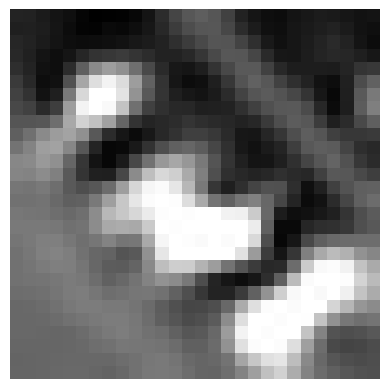

In [11]:
import matplotlib.pyplot as plt

plt.imshow(X[0], cmap="gray")
plt.axis("off")
plt.show()

Contoh foto di dataset train

In [12]:
print(X[0])

[[ 35  34  27  20  15   5   0   1   2   7  20  44  69  87  94  86  66  34
   21  14  12  20  24  28  26  22  18  20]
 [ 31  33  29  21  12   4   3  10   8  14  23  40  60  77  86  87  71  45
   28  16  14  22  26  30  34  27  18  15]
 [ 38  34  27  20  14  12  13  15  18  24  28  34  47  60  74  85  84  67
   47  25  16  22  28  35  42  34  20  12]
 [ 41  32  20  14  21  38  51  55  59  53  44  34  34  41  54  74  87  86
   70  42  23  22  29  37  41  38  31  23]
 [ 46  35  17  14  44  95 138 157 144 111  74  42  24  21  30  51  72  89
   89  65  41  29  29  29  28  37  53  56]
 [ 58  41  13  17  81 166 222 244 220 157  97  51  22  12  15  31  55  83
   97  87  65  47  34  18  13  33  76  97]
 [ 66  50  18  31 122 216 255 255 228 148  88  52  31  23  19  27  43  67
   85  91  83  71  53  23   8  31  89 121]
 [ 72  66  42  62 157 243 255 249 195 112  64  48  41  39  31  33  34  49
   64  80  88  89  75  39  11  30  92 127]
 [ 85  85  87 110 168 210 193 161 101  51  37  40  44  52  46  4

Output print(X[0]) menunjukkan data citra pertama pada dataset dalam bentuk matriks berukuran 28 × 28, di mana setiap elemen matriks merepresentasikan nilai intensitas piksel pada citra grayscale. Nilai piksel berada pada rentang 0–255, dengan 0 menunjukkan warna hitam, 255 menunjukkan warna putih, sedangkan nilai di antaranya merepresentasikan berbagai tingkat keabuan.

### Test

In [13]:
import os

print(os.path.exists(folder))
print(os.listdir(folder))

True
['60005.jpg', '57344.jpg', '57199.jpg', '63951.jpg', '58867.jpg', '60082.jpg', '67061.jpg', '56018.jpg', '61889.jpg', '56678.jpg', '61792.jpg', '64625.jpg', '58634.jpg', '56476.jpg', '62736.jpg', '58244.jpg', '68111.jpg', '67294.jpg', '62662.jpg', '64425.jpg', '58145.jpg', '66327.jpg', '66946.jpg', '56560.jpg', '66999.jpg', '59343.jpg', '63077.jpg', '63072.jpg', '56482.jpg', '62656.jpg', '66662.jpg', '61727.jpg', '59471.jpg', '57788.jpg', '59304.jpg', '63829.jpg', '56357.jpg', '61108.jpg', '64735.jpg', '60034.jpg', '59266.jpg', '60772.jpg', '64104.jpg', '55457.jpg', '56378.jpg', '65156.jpg', '67027.jpg', '62128.jpg', '57116.jpg', '57545.jpg', '62215.jpg', '63105.jpg', '57100.jpg', '65362.jpg', '60720.jpg', '63893.jpg', '57859.jpg', '67849.jpg', '65358.jpg', '64659.jpg', '66468.jpg', '65920.jpg', '61692.jpg', '59493.jpg', '62372.jpg', '65104.jpg', '60197.jpg', '59171.jpg', '59922.jpg', '62802.jpg', '61645.jpg', '66929.jpg', '56712.jpg', '55865.jpg', '59618.jpg', '66365.jpg', '62262

In [14]:
X_test = []

for kelas in ["car", "plane"]:
    folder = f"/content/drive/MyDrive/DeepLearning_UAS/Test/{kelas}"

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28,28))

        X_test.append(img)

X_test = np.array(X_test)

In [15]:
print(len(X_test))

1784


Terdapat 1784 data test

In [19]:
print(X_test.shape)

(1784, 28, 28)


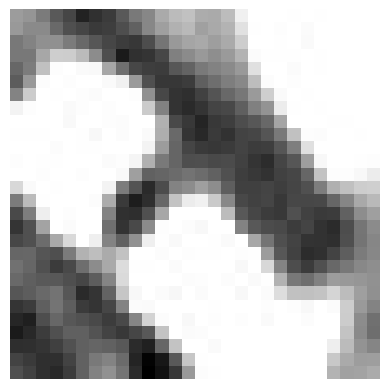

In [20]:
plt.imshow(X_test[0], cmap="gray")
plt.axis("off")
plt.show()

Gambar diatas adalah contoh images pada dataset yang digunakan untuk class car

In [21]:
print(X_test)

[[[166 160 137 ... 255 255 255]
  [164 150 150 ... 255 255 255]
  [134 145 156 ... 255 255 255]
  ...
  [ 68  69  74 ... 194 159 146]
  [ 87  79  69 ... 179 167 168]
  [ 98  85  69 ... 171 173 180]]

 [[ 37  31  23 ...  28  31  32]
  [ 36  31  25 ...  32  35  34]
  [ 36  32  28 ...  37  43  45]
  ...
  [ 31  33  33 ...  27  33  34]
  [ 20  28  37 ...  36  33  30]
  [ 21  28  37 ...  42  33  28]]

 [[ 82  75  78 ... 255 251 231]
  [ 90  77  77 ... 254 255 248]
  [ 98  89  79 ... 253 253 255]
  ...
  [ 80  74  62 ...  87 101 105]
  [ 86  77  73 ...  85 109 115]
  [ 87  81  78 ...  87 114 115]]

 ...

 [[255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  ...
  [255 253 253 ... 254 255 255]
  [252 255 255 ... 254 255 255]
  [232 249 254 ... 255 255 255]]

 [[255 115  50 ... 255 255 251]
  [255  62 166 ... 255 250 255]
  [252 202 255 ... 251 255 255]
  ...
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 2

•⁠  ⁠Training: 14.240 gambar

•⁠  ⁠Testing: 1.784 gambar

•⁠  ⁠Keseluruhan: 16.024 gambar


Kode ini untuk menunjukkan jumlah gambar pada masing-masing kelas. Sperti yang sudah dimention sebelumnya, pembagiannya seimbang yang artinya dataset tidak mengalami class imbalance sehingga model tidak akan mempelajari salah satu kelas lebih dominan.

### Scaling

Tahap scaling dilakukan dengan melakukan normalisasi nilai piksel dari rentang 0–255 menjadi 0–1 menggunakan pembagian terhadap 255. Normalisasi ini bertujuan untuk menyamakan skala seluruh data masukan sehingga proses pembelajaran model menjadi lebih stabil. Selain itu, nilai piksel yang berada pada rentang 0–1 juga sesuai dengan fungsi aktivasi sigmoid pada layer output Autoencoder, sehingga model dapat melakukan proses rekonstruksi gambar dengan lebih optimal.

In [22]:
print(X.min(), X.max())

0 255


In [23]:
X = X.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(X.shape)
print(X_test.shape)

(14240, 28, 28)
(1784, 28, 28)


In [24]:
print(X.min(), X.max())

0.0 1.0


In [25]:
print(X_test.min(), X_test.max())

0.0 1.0


### Channel 3 RGB

Tahap ini dilakukan dengan menambahkan dimensi channel pada setiap citra sehingga bentuk data berubah dari (28, 28) menjadi (28, 28, 1). Penambahan dimensi ini diperlukan karena gambar yang digunakan merupakan citra grayscale yang hanya memiliki satu channel.

Selain itu, layer Conv2D pada Autoencoder mengharapkan masukan dalam format (tinggi, lebar, channel), sehingga data perlu diubah menjadi (28, 28, 1) agar dapat diproses dengan benar oleh model.

In [26]:
print(X.shape)
print(X_test.shape)

(14240, 28, 28)
(1784, 28, 28)


Data ditambahkan satu dimensi channel sehingga ukurannya dari 28 x 28 berubah menjadi 28 x 28 x 1.

Hal ini dilakukan karena gambar bersifat grayscale dan model Autoencoder pada soal mengharapkan input dengan satu channel agar proses konvolusi dapat berjalan dengan benar.

In [27]:
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [28]:
print(X.shape)
print(X_test.shape)

(14240, 28, 28, 1)
(1784, 28, 28, 1)


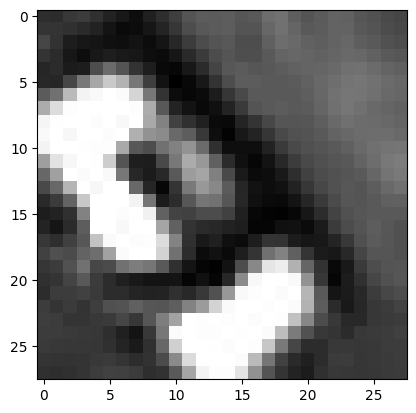

In [29]:
plt.imshow(X[12], cmap="gray")

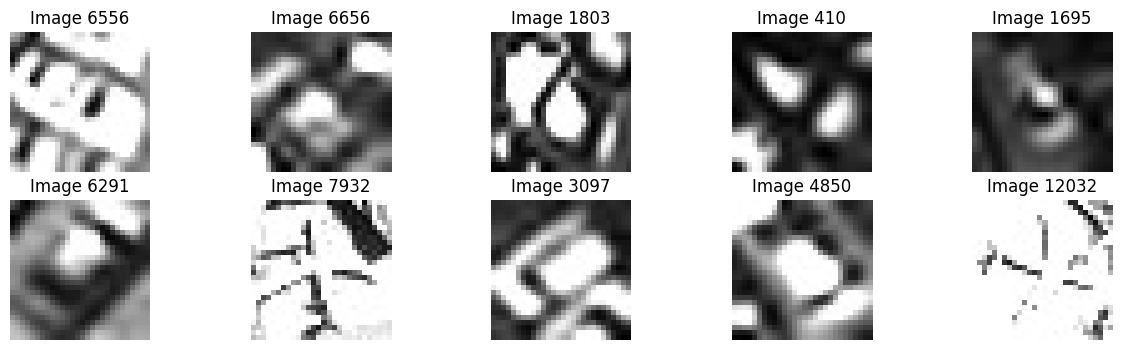

In [30]:
random_idx = np.random.choice(len(X), 10, replace=False)

plt.figure(figsize=(15,4))

for i, idx in enumerate(random_idx):
    plt.subplot(2,5,i+1)
    plt.imshow(X[idx].squeeze(), cmap="gray")
    plt.title(f"Image {idx}")
    plt.axis("off")

plt.show()

seluruh citra telah diproses menjadi grayscale dengan ukuran input 28 x 28 x 1, di mana dimensi 28 x 28 menunjukkan tinggi dan lebar gambar, sedangkan 1 menunjukkan bahwa setiap gambar hanya memiliki satu channel (grayscale).

Resolusi gambar rendah akibat proses resize menjadi 28 x 28 px, tapi bisa dilihat kalau bentuk utama objek seperti mobil dan pesawat masih dapat dikenali.


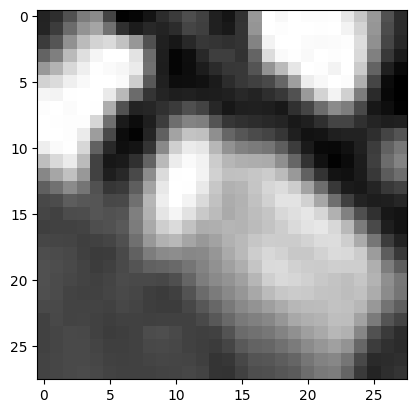

In [32]:
plt.imshow(X_test[12], cmap="gray")

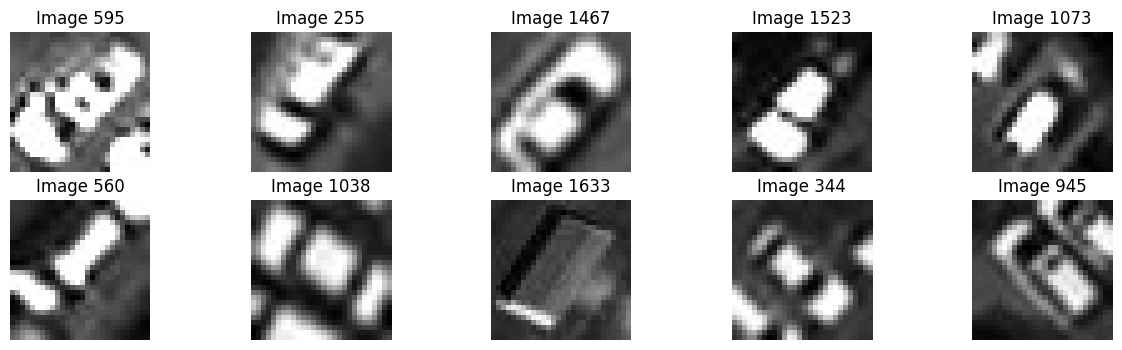

In [33]:
random_idx_t = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15,4))

for i, idx in enumerate(random_idx_t):
    plt.subplot(2,5,i+1)
    plt.imshow(X[idx].squeeze(), cmap="gray")
    plt.title(f"Image {idx}")
    plt.axis("off")

plt.show()

## Split 80% Train, 10% Validation, 10% Test

Di soal train dan test sudah dibagi di 2 folder yang berbeda sehingga untuk membagi 80:10:10 yang pertama dilakukan adalah menggabungkan kedua dataset lalu baru bisa dilakukan splitting data sebanyak 80% train : 10% validation : 10% test

In [35]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = 28

X = []
y = []

folders = [
    ("/content/drive/MyDrive/DeepLearning_UAS/Train/car", 0),
    ("/content/drive/MyDrive/DeepLearning_UAS/Test/car", 0),
    ("/content/drive/MyDrive/DeepLearning_UAS/Train/plane", 1),
    ("/content/drive/MyDrive/DeepLearning_UAS/Test/plane", 1)
]

for folder, label in folders:
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

# Tambahkan channel
X = X.reshape(-1, 28, 28, 1)

print("Total data :", len(X))
print("Label shape:", y.shape)

Total data : 16024
Label shape: (16024,)


In [36]:
# 80% Train
# 20% untuk Validation + Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
    shuffle=True
)

# 20% dibagi dua menjadi
# 10% Validation
# 10% Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
    shuffle=True
)

print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

Train      : (12819, 28, 28, 1)
Validation : (1602, 28, 28, 1)
Test       : (1603, 28, 28, 1)


In [37]:
print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

print("Train label :", y_train.shape)
print("Val label   :", y_val.shape)
print("Test label  :", y_test.shape)

Train      : (12819, 28, 28, 1)
Validation : (1602, 28, 28, 1)
Test       : (1603, 28, 28, 1)
Train label : (12819,)
Val label   : (1602,)
Test label  : (1603,)


In [38]:
import numpy as np

print("Train:", np.bincount(y_train))
print("Validation:", np.bincount(y_val))
print("Test:", np.bincount(y_test))

Train: [6409 6410]
Validation: [801 801]
Test: [802 801]


Seluruh dataset yang terdiri dari 16.024 gambar (gabungan folder Train dan Test untuk kelas Car dan Plane) terlebih dahulu digabungkan, kemudian diacak (shuffle) dan dibagi menggunakan train_test_split() dengan perbandingan 80% data training, 10% data validation, dan 10% data testing. Hasil pembagian menghasilkan 12.819 data training, 1.602 data validation, dan 1.603 data testing.

Data training terdiri dari 6.409 gambar car dan 6.410 gambar plane, data validation masing-masing 801 gambar, sedangkan data testing terdiri dari 802 gambar car dan 801 gambar plane. Data ini menunjukkan angka yang seimbang.


# POIN B : Baseline

Model baseline dibangun mengikuti arsitektur Autoencoder yang telah ditentukan pada soal tanpa melakukan perubahan pada jumlah layer maupun jumlah neuron. Arsitektur ini digunakan sebagai acuan (baseline) untuk membandingkan performa dengan model hasil modifikasi pada tahap berikutnya.

Arsitektur terdiri atas dua bagian, yaitu encoder dan decoder.

In [40]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Flatten,
    Dense,
    Reshape
)

from tensorflow.keras.models import Model

#### Build Encoder

In [41]:
# Input (28x28x1)
input_img = Input(shape=(28,28,1))

# Conv + ReLU 28x28x32
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)

# Max Pool 14x14x32
x = MaxPooling2D((2,2), padding='same')(x)

# Flatten 6272
x = Flatten()(x)

# Fully Connected + ReLU Latent 128
latent = Dense(128, activation='relu')(x)

In [42]:
encoder = Model(input_img, latent, name="Encoder")
encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,264 (3.06 MB)

 Trainable params: 803,264 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

•⁠  ⁠Input Layer menerima citra grayscale berukuran 28 × 28 × 1.

•⁠  ⁠Conv2D mengekstraksi fitur awal seperti pola tepi, tekstur, dan bentuk sederhana.

•⁠  ⁠MaxPooling2D mengurangi ukuran feature map dari 28 × 28 × 32 menjadi 14 × 14 × 32, sehingga jumlah data yang diproses menjadi lebih sedikit sekaligus mempertahankan fitur penting.

•⁠  ⁠Flatten mengubah feature map menjadi vektor satu dimensi sepanjang 6272 elemen.

•⁠  ⁠Dense (128 neuron, ReLU) menghasilkan latent vector berdimensi 128 sebagai representasi terkompresi dari gambar.

#### Build Decoder

In [46]:
latent_input = Input(shape=(128,))

# Fully Connected6272
x = Dense(14 * 14 * 32)(latent_input)

# Reshape 14x14x32
x = Reshape((14, 14, 32))(x)

# UpSampling 28x28x32
x = UpSampling2D((2, 2))(x)

# Conv + ReLU 28x28x32
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

# Conv + Sigmoid 28x28x1
decoder_output = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)


•⁠  ⁠Dense mengubah latent vector menjadi 6272 neuron.

•⁠  ⁠Reshape mengembalikan bentuk data menjadi 14 × 14 × 32.

•⁠  ⁠UpSampling2D (2×2) memperbesar ukuran feature map menjadi 28 × 28 × 32.

•⁠  ⁠Conv2D (32 filter, ReLU) memperhalus hasil rekonstruksi dan menyusun kembali fitur-fitur gambar.

•⁠  ⁠Conv2D (1 filter, Sigmoid) menghasilkan citra keluaran berukuran 28 × 28 × 1 dengan nilai piksel berada pada rentang 0–1.

### Autoencoder

In [48]:
decoder = Model(latent_input, decoder_output, name="Decoder")

autoencoder = Model(
    inputs=input_img,
    outputs=decoder(encoder(input_img)),
    name="Autoencoder"
)

autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28, 1)      │       818,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

Encoder dan decoder kemudian digabungkan menjadi satu model Autoencoder. Model dilatih menggunakan optimizer Adam, fungsi loss MSE (Mean Squared Error), serta metrik evaluasi MAE (Mean Absolute Error).

In [50]:
history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=32,
    shuffle=True
)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0371 - mae: 0.1412 - val_loss: 0.0234 - val_mae: 0.1082
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0199 - mae: 0.0978 - val_loss: 0.0175 - val_mae: 0.0915
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0159 - mae: 0.0857 - val_loss: 0.0153 - val_mae: 0.0833
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0146 - mae: 0.0812 - val_loss: 0.0144 - val_mae: 0.0808
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0139 - mae: 0.0790 - val_loss: 0.0141 - val_mae: 0.0798
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0135 - mae: 0.0777 - val_loss: 0.0139 - val_mae: 0.0789
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0132 - mae: 0.0765 - val_loss: 0.0135 - val_mae: 0.0767
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0129 - mae: 0.0754 - val_loss: 0.0132 - val_mae: 0.0760
Epoch 9/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - 

## Train Evaluation

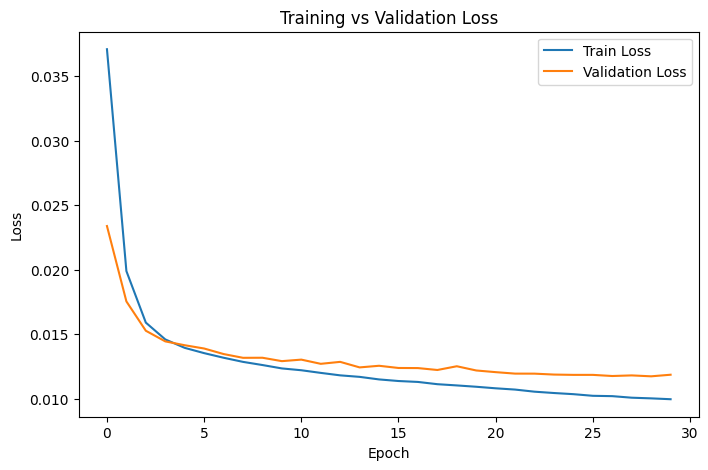

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [52]:
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])

print("Best Epoch :", best_epoch)
print("Best Validation Loss :", best_val_loss)

Best Epoch : 29
Best Validation Loss : 0.011736348271369934


Grafik menunjukkan bahwa training loss dan validation loss sama-sama menurun selama proses pelatihan, sehingga model berhasil mempelajari pola data dengan baik. Kedua kurva juga masih cukup berdekatan sehingga belum terlihat adanya overfitting yang berarti. Validation loss terbaik diperoleh pada epoch ke-29 sebesar 0,0117.

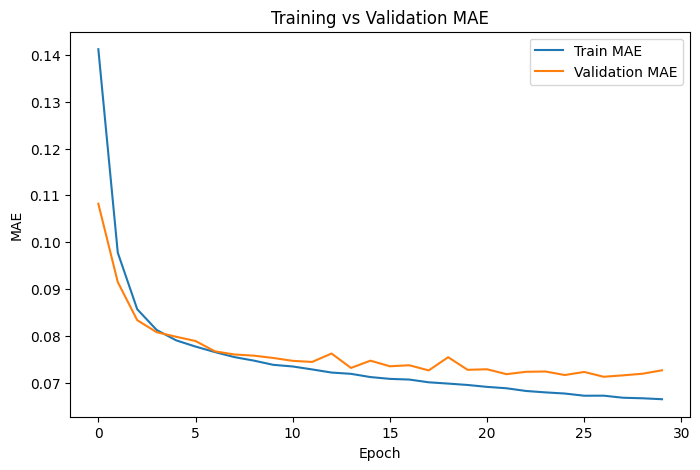

In [53]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()

plt.show()

In [54]:
print("Train MAE :", history.history['mae'][-1])
print("Val MAE :", history.history['val_mae'][-1])

Train MAE : 0.06645075231790543
Val MAE : 0.0726277232170105


Grafik menunjukkan bahwa nilai training MAE dan validation MAE terus menurun selama proses pelatihan, yang berarti rata-rata kesalahan rekonstruksi gambar semakin kecil. Kedua kurva juga memiliki jarak yang relatif dekat meskipun validation MAE sedikit lebih tinggi dibandingkan training MAE

diperoleh training MAE sebesar 0,0665 dan validation MAE sebesar 0,0726, yang menunjukkan bahwa hasil rekonstruksi model sudah cukup mendekati gambar aslinya.

## Test Prediction

In [55]:
decoded = autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [56]:
test_loss_mod, test_mae_mod = autoencoder.evaluate(
    X_test,
    X_test,
    verbose=0
)

print("Test Loss :", test_loss_mod)
print("Test MAE  :", test_mae_mod)

Test Loss : 0.012107034213840961
Test MAE  : 0.07367128133773804


Nilai Test Loss sebesar 0,0121 menunjukkan bahwa model mampu merekonstruksi gambar pada data uji dengan tingkat kesalahan yang relatif rendah.

Test MAE sebesar 0,07363 menunjukkan bahwa rata-rata kesalahan absolut pada setiap piksel relatif kecil. Hasil ini mengindikasikan bahwa model memiliki kemampuan rekonstruksi yang cukup baik pada data yang belum pernah dilihat sebelumnya.

## Evaluasi Structural Similarity Index (SSIM)

In [57]:
from skimage.metrics import structural_similarity as ssim

scores = []

for i in range(len(X_test)):
    score = ssim(
        X_test[i].squeeze(),
        decoded[i].squeeze(),
        data_range=1.0
    )
    scores.append(score)

print("Average SSIM =", np.mean(scores))

Average SSIM = 0.732148343693169


Evaluasi kualitas hasil rekonstruksi dilakukan menggunakan Structural Similarity Index (SSIM). Penilaian SSIM adalah berdasarkan kemiripan struktur, pola, kontras, dan tingkat kecerahan antara gambar asli dan gambar hasil rekonstruksi.

Karena nilai SSIM berada pada rentang 0 sampai 1, maka semakin mendekati 1 menunjukkan bahwa gambar hasil rekonstruksi semakin mirip dengan gambar asli.

Nilai Average SSIM sebesar 0.7321 menunjukkan bahwa gambar hasil rekonstruksi memiliki tingkat kemiripan sekitar 73% dengan gambar asli. Artinya, bentuk dan pola utama pada gambar masih dapat dipertahankan, meskipun beberapa detail kecil masih hilang yang bisa jadi karena adanya proses kompres. Nilai ini masih bisa ditingkatkan dengan rekonstruksi arsitektur dan hyperparameter tuning yang akan saya lakukan di poin c.


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


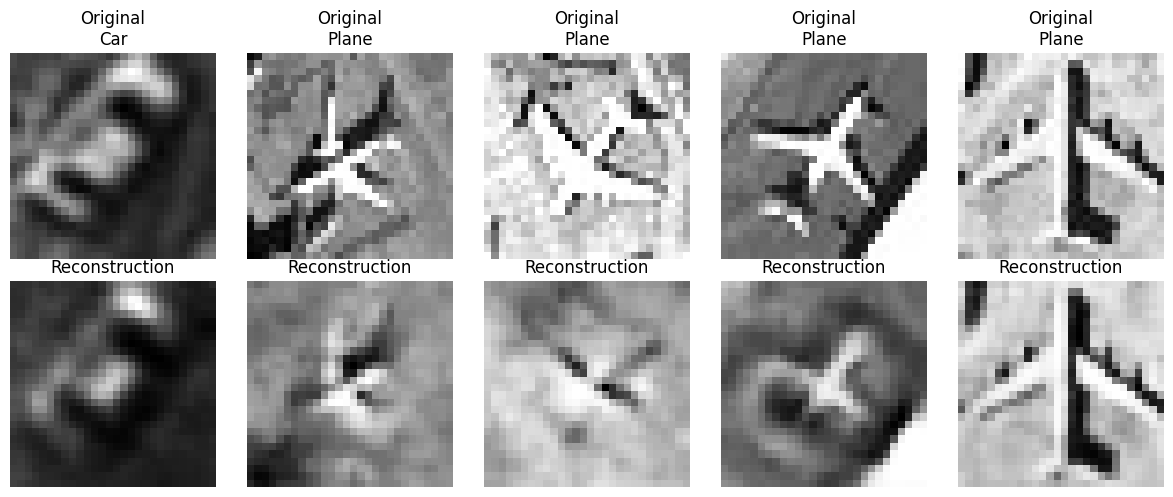

In [58]:
label_name = {0: "Car", 1: "Plane"}

decoded_test = autoencoder.predict(X_test)

np.random.seed(42)
idx = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,5))

for i, j in enumerate(idx):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[j].squeeze(), cmap='gray')
    plt.title(f"Original\n{label_name[y_test[j]]}")
    plt.axis('off')

    # Reconstruction
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_test[j].squeeze(), cmap='gray')
    plt.title("Reconstruction")
    plt.axis('off')

plt.tight_layout()
plt.show()

Gambar pada baris pertama merupakan citra asli dari data original. Baris kedua merupakan citra hasil rekonstruksi yang dihasilkan oleh Autoencoder. Bisa dilihat kalau bentuk objek pada hasil rekonstruksi masih menyerupai gambar asli sehingga menunjukkan bahwa model berhasil mempelajari informasi penting dari data.

Namun, beberapa hasil rekonstruksi terlihat lebih blur dibandingkan gambar asli. Hal ini terjadi karena Autoencoder melakukan kompresi dimensi dari 784 fitur menjadi 128 fitur yang artinya sebagian informasi detail hilang selama proses encoding dan decoding.

### Kesimpulan Baseline

Secara keseluruhan, model baseline belum bekerja dengan baik sehingga masih harus melakukan tuning.

# POIN C : Tuning Model

Pada model baseline, nilai SSIM yang diperoleh sebesar 0.7321. Meskipun hasil rekonstruksi sudah cukup baik, beberapa detail gambar masih terlihat kurang jelas. Oleh karena itu dilakukan modifikasi arsitektur dan tuning hyperparameter untuk meningkatkan kemampuan model dalam mempertahankan informasi penting selama proses dimension reduction.



#### Modified 1

In [59]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [60]:
from tensorflow.keras.layers import *

input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Flatten()(x)

latent = Dense(
    128,
    activation='relu',
    name='latent'
)(x)

# Decoder

x = Dense(
    14*14*64,
    activation='relu'
)(latent)

x = Reshape((14,14,64))(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

output = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

modified_autoencoder = Model(
    input_img,
    output
)

modified_autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modified_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12544)          │     1,618,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,317,697 (12.66 MB)

 Trainable params: 3,317,441 (12.66 MB)

 Non-trainable params: 256 (1.00 KB)

Pada Modified 1, arsitektur Autoencoder masih mempertahankan struktur encoder dan decoder seperti pada model baseline. Namun, beberapa perubahan dilakukan pada bagian encoder, yaitu jumlah filter Conv2D ditingkatkan dari 32 menjadi 64, ditambahkan satu layer Conv2D sehingga encoder menjadi lebih dalam, serta ditambahkan Batch Normalization setelah layer konvolusi untuk membantu menstabilkan proses pelatihan dan mempercepat konvergensi model. Latent dimension tetap dipertahankan sebesar 128, sehingga proses dimension reduction tidak berubah, tetapi representasi fitur yang dihasilkan menjadi lebih informatif karena encoder mampu mengekstraksi lebih banyak pola dari citra masukan.

Pada bagian decoder, jumlah filter juga disesuaikan agar seimbang dengan encoder, yaitu dimulai dari 64 filter kemudian dikurangi menjadi 32 filter sebelum menghasilkan citra keluaran berukuran 28 × 28 × 1. Decoder tetap berfungsi merekonstruksi citra dari latent space menjadi gambar asli. Model dikompilasi menggunakan optimizer Adam, loss function MSE, dan MAE sebagai metrik evaluasi. Selain itu, jumlah epoch ditingkatkan menjadi 50 dengan batch size 32 untuk memberikan waktu belajar yang lebih lama sehingga kualitas rekonstruksi dapat meningkat dibandingkan model baseline.

In [61]:
history_mod = modified_autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0320 - mae: 0.1282 - val_loss: 0.1868 - val_mae: 0.3617
Epoch 2/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0184 - mae: 0.0941 - val_loss: 0.0184 - val_mae: 0.0976
Epoch 3/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0163 - mae: 0.0869 - val_loss: 0.0159 - val_mae: 0.0860
Epoch 4/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0154 - mae: 0.0838 - val_loss: 0.0150 - val_mae: 0.0813
Epoch 5/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0147 - mae: 0.0816 - val_loss: 0.0151 - val_mae: 0.0817
Epoch 6/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0142 - mae: 0.0799 - val_loss: 0.0143 - val_mae: 0.0805
Epoch 7/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0139 - mae: 0.0792 - val_loss: 0.0143 - val_mae: 0.0790
Epoch 8/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0134 - mae: 0.0776 - val_loss: 0.0138 - val_mae: 0.0777
Epoch 9/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

### Train Evaluation

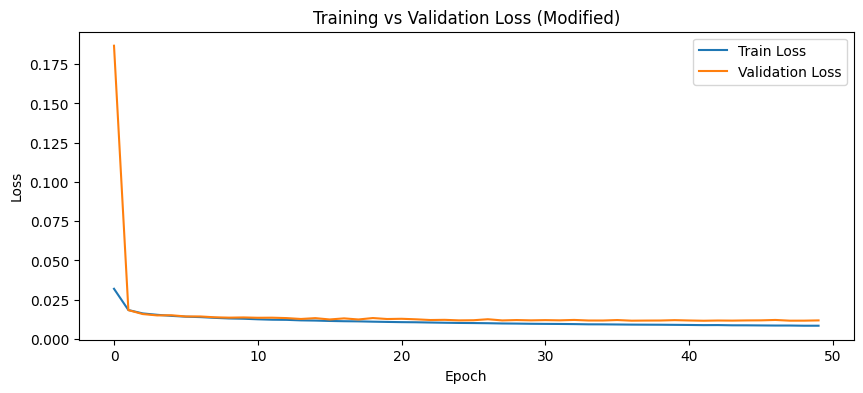

In [62]:
plt.figure(figsize=(10,4))

plt.plot(history_mod.history['loss'], label='Train Loss')
plt.plot(history_mod.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Modified)')
plt.legend()

plt.show()

In [63]:
best_epoch_mod = np.argmin(history_mod.history['val_loss']) + 1
best_val_loss_mod = np.min(history_mod.history['val_loss'])

print("Best Epoch :", best_epoch_mod)
print("Best Validation Loss :", best_val_loss_mod)

Best Epoch : 42
Best Validation Loss : 0.011600811034440994


Dibandingkan dengan model baseline, training loss dan validation loss pada Modified 1 mengalami penurunan yang lebih cepat dan mencapai nilai yang lebih rendah. Hal ini menunjukkan bahwa perubahan arsitektur, seperti penambahan layer Conv2D, peningkatan jumlah filter dari 32 menjadi 64, serta penambahan Batch Normalization, membantu model mempelajari representasi fitur yang lebih baik sehingga kesalahan rekonstruksi berkurang. Latent dimension tetap dipertahankan sebesar 128, sehingga peningkatan performa berasal dari kemampuan encoder dalam mengekstraksi fitur yang lebih kaya, bukan dari penambahan ukuran latent space.

Berdasarkan grafik, kurva training loss dan validation loss saling berdekatan sehingga proses pembelajaran berlangsung stabil dan kemampuan generalisasi model tetap terjaga. Validation loss terbaik diperoleh pada epoch ke-42 dengan nilai sekitar 0,0116, yang lebih rendah dibandingkan model baseline. Hasil ini menunjukkan bahwa modifikasi arsitektur pada Modified 1 berhasil meningkatkan kualitas rekonstruksi gambar.

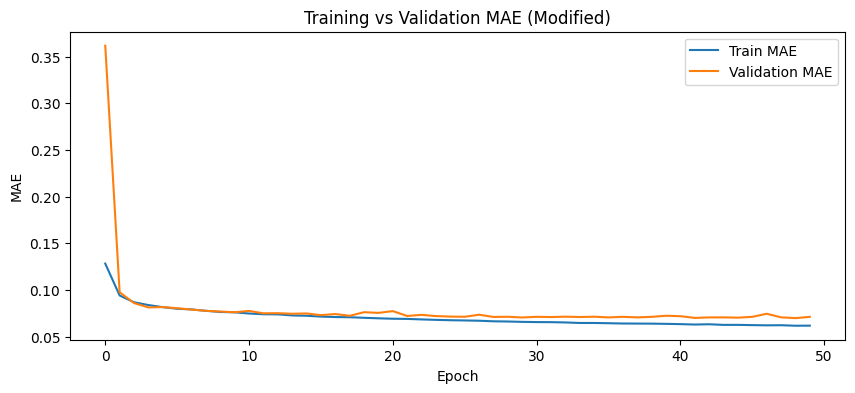

In [64]:
plt.figure(figsize=(10,4))

plt.plot(history_mod.history['mae'], label='Train MAE')
plt.plot(history_mod.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE (Modified)')
plt.legend()

plt.show()

In [65]:
print("Train Loss :", history_mod.history['loss'][-1])
print("Val Loss   :", history_mod.history['val_loss'][-1])

print("Train MAE  :", history_mod.history['mae'][-1])
print("Val MAE    :", history_mod.history['val_mae'][-1])

Train Loss : 0.008427614346146584
Val Loss   : 0.011815780773758888
Train MAE  : 0.06177476793527603
Val MAE    : 0.07121086865663528


Nilai MAE pada model Modified 1 juga mengalami penurunan dibandingkan model baseline, yang menunjukkan bahwa rata-rata kesalahan rekonstruksi setiap piksel semakin kecil. Hal ini menandakan bahwa penambahan layer konvolusi, Batch Normalization membantu model mempelajari gambar dengan lebih baik sehingga lebih akurat.

kurva training MAE dan validation MAE terus menurun dan memiliki jarak yang relatif kecil selama proses pelatihan. Kondisi ini menunjukkan bahwa model belajar secara stabil tanpa indikasi overfitting.



## Test Prediction

In [66]:
decoded_mod = modified_autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [67]:
test_loss_mod, test_mae_mod = modified_autoencoder.evaluate(
    X_test,
    X_test,
    verbose=0
)

print("Test Loss :", test_loss_mod)
print("Test MAE  :", test_mae_mod)

Test Loss : 0.011817297898232937
Test MAE  : 0.07105960696935654


Nilai test loss sebesar 0.011menunjukkan bahwa rata-rata kesalahan rekonstruksi pada data uji sangat kecil. Artinya, gambar hasil rekonstruksi memiliki perbedaan yang rendah dibandingkan gambar aslinya.

Nilai MAE sebesar 0.071 berarti rata-rata selisih setiap piksel hanya sekitar 7% dari rentang nilai piksel. Nilai ini cukup kecil tapi masih menunjukkan hasil rekonstruksi belum cukup akurat.


## Evaluasi SSIM

In [68]:
scores_mod = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        decoded_mod[i].squeeze(),
        data_range=1.0
    )

    scores_mod.append(score)

avg_ssim_mod = np.mean(scores_mod)

print("Average SSIM =", avg_ssim_mod)

Average SSIM = 0.7431584908224914


Nilai Average SSIM sebesar 0,7432 menunjukkan bahwa gambar hasil rekonstruksi memiliki tingkat kemiripan struktur yang cukup baik dengan gambar asli. Dibandingkan model baseline (0,73) sehingga dapat disimpulkan bahwa modifikasi arsitektur pada Modified 1 berhasil meningkatkan kualitas rekonstruksi serta mempertahankan informasi visual dengan lebih baik.

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


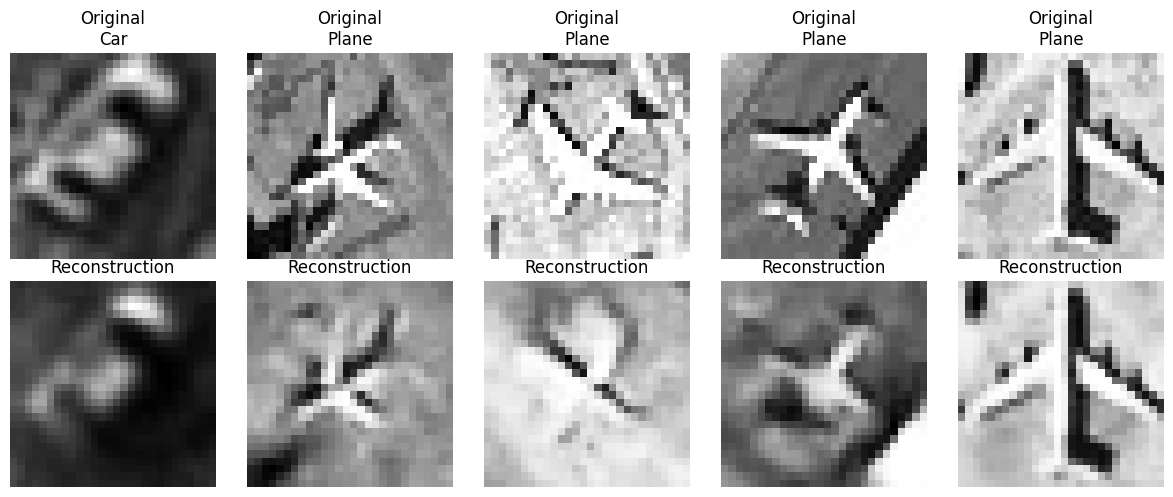

In [69]:
label_name = {0: "Car", 1: "Plane"}

decoded_test = modified_autoencoder.predict(X_test)

np.random.seed(42)
idx = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,5))

for i, j in enumerate(idx):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[j].squeeze(), cmap='gray')
    plt.title(f"Original\n{label_name[y_test[j]]}")
    plt.axis('off')

    # Reconstruction
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_test[j].squeeze(), cmap='gray')
    plt.title("Reconstruction")
    plt.axis('off')

plt.tight_layout()
plt.show()

Modified 1 sudah mampu mempertahankan bentuk utama objek, baik pada kelas Car maupun Plane. Dibandingkan model baseline, hasil rekonstruksi terlihat lebih jelas dengan kontur objek yang lebih mudah dikenali, meskipun masih terdapat sedikit efek blur dan beberapa detail halus belum sepenuhnya dipertahankan.

## Modified 2

Pada Modified 2, arsitektur Autoencoder kembali dikembangkan dengan meningkatkan jumlah filter konvolusi dari 64 menjadi 128 pada encoder dan decoder, serta menambahkan Batch Normalization pada setiap blok konvolusi.

Selanjutnya, ditambahkan Dropout sebesar 0,2 sebelum latent layer untuk membantu mengurangi overfitting dan meningkatkan kemampuan generalisasi model. Latent dimension tetap dipertahankan sebesar 128, sehingga proses dimension reduction tidak berubah.

Dibandingkan dengan Modified 1, jumlah filter yang lebih banyak memungkinkan model mempelajari fitur visual yang lebih kompleks, sedangkan kombinasi Batch Normalization dan Dropout membantu menghasilkan proses pelatihan yang lebih stabil sehingga kualitas rekonstruksi gambar diharapkan menjadi lebih baik.

In [70]:
input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = BatchNormalization()(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Flatten()(x)

x = Dropout(0.2)(x)

latent = Dense(
    128,
    activation='relu',
    name='latent'
)(x)

# Decoder


x = Dense(
    14*14*128,
    activation='relu'
)(latent)

x = Reshape((14,14,128))(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

output = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

modified2_autoencoder = Model(input_img, output)

modified2_autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modified2_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25088)          │     3,236,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,820,353 (26.02 MB)

 Trainable params: 6,819,457 (26.01 MB)

 Non-trainable params: 896 (3.50 KB)

In [71]:
history_mod2 = modified2_autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - loss: 0.0297 - mae: 0.1218 - val_loss: 0.0963 - val_mae: 0.2593
Epoch 2/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0161 - mae: 0.0874 - val_loss: 0.0159 - val_mae: 0.0871
Epoch 3/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0133 - mae: 0.0782 - val_loss: 0.0130 - val_mae: 0.0737
Epoch 4/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0114 - mae: 0.0711 - val_loss: 0.0136 - val_mae: 0.0831
Epoch 5/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0104 - mae: 0.0673 - val_loss: 0.0169 - val_mae: 0.0980
Epoch 6/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0096 - mae: 0.0642 - val_loss: 0.0094 - val_mae: 0.0631
Epoch 7/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0090 - mae: 0.0625 - val_loss: 0.0089 - val_mae: 0.0598
Epoch 8/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0086 - mae: 0.0605 - val_loss: 0.0097 - val_mae: 0.0678
Epoch 9/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms

### Train Evaluation

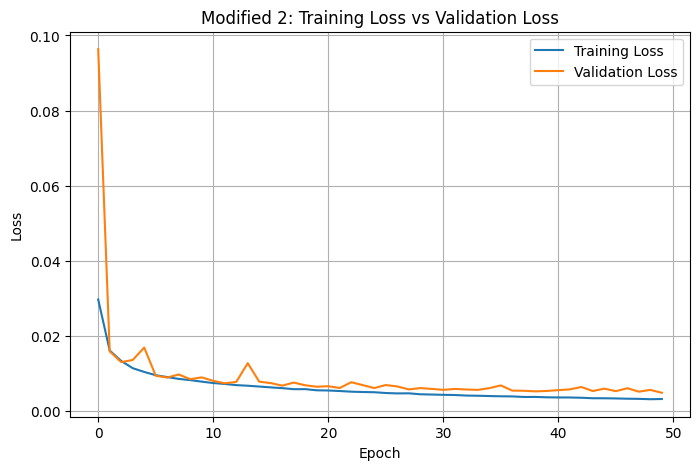

In [72]:
plt.figure(figsize=(8,5))

plt.plot(history_mod2.history['loss'], label='Training Loss')
plt.plot(history_mod2.history['val_loss'], label='Validation Loss')

plt.title('Modified 2: Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [73]:
best_epoch_mod2 = np.argmin(history_mod2.history['val_loss']) + 1
best_val_loss_mod2 = np.min(history_mod2.history['val_loss'])

print("Best Epoch :", best_epoch_mod2)
print("Best Validation Loss :", best_val_loss_mod2)

Best Epoch : 50
Best Validation Loss : 0.0048670899122953415


Training loss dan validation loss menurun secara konsisten pada awal proses pelatihan, menandakan model berhasil mempelajari pola data. Nilai validation loss terbaik diperoleh pada epoch ke-50, yaitu sebesar 0,00486.

Dibandingkan dengan Modified 1, penurunan loss ini menunjukkan bahwa penambahan jumlah filter dan penggunaan Dropout 0,2 berhasil meningkatkan kemampuan model dalam merekonstruksi gambar sehingga hasil rekonstruksi menjadi lebih mendekati gambar asli.

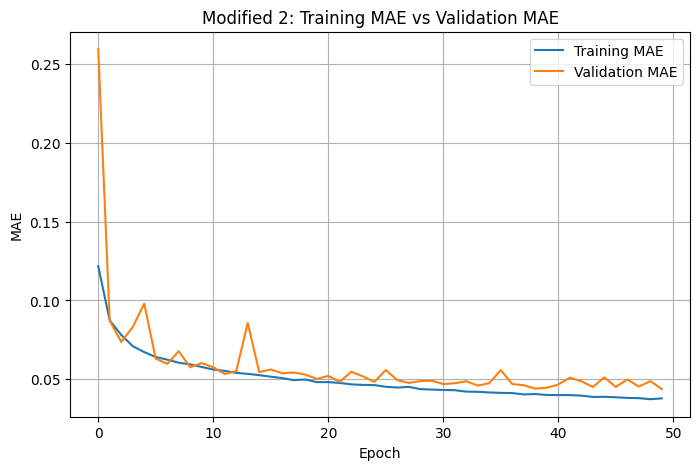

In [74]:
plt.figure(figsize=(8,5))

plt.plot(history_mod2.history['mae'], label='Training MAE')
plt.plot(history_mod2.history['val_mae'], label='Validation MAE')

plt.title('Modified 2: Training MAE vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.show()

In [75]:
print("Train Loss :", history_mod2.history['loss'][-1])
print("Val Loss   :", history_mod.history['val_loss'][-1])

print("Train MAE  :", history_mod2.history['mae'][-1])
print("Val MAE    :", history_mod2.history['val_mae'][-1])

Train Loss : 0.0032058663200587034
Val Loss   : 0.011815780773758888
Train MAE  : 0.037942059338092804
Val MAE    : 0.043827708810567856


Nilai MAE pada Modified 2 terus menurun hingga mencapai Train MAE sebesar 0,0379 dan Validation MAE sebesar 0,0438. Selisih kedua nilai yang kecil serta kurva yang relatif berdekatan menunjukkan bahwa model mampu melakukan generalisasi dengan baik tanpa indikasi overfitting. Hasil ini juga menunjukkan bahwa penambahan jumlah filter dan Dropout 0,2 berhasil meningkatkan akurasi rekonstruksi dibandingkan model sebelumnya.

### Test Prediction

In [76]:
decoded_mod2 = modified2_autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


In [77]:
test_loss_mod2, test_mae_mod2 = modified2_autoencoder.evaluate(
    X_test,
    X_test,
    verbose=0
)

print("Test Loss :", test_loss_mod2)
print("Test MAE  :", test_mae_mod2)

Test Loss : 0.005022640805691481
Test MAE  : 0.044469062238931656


Pada data uji, model memperoleh Test Loss sebesar 0,005 dan Test MAE sebesar 0,044. Nilai yang rendah ini menunjukkan bahwa model mampu merekonstruksi gambar dengan baik serta memiliki kemampuan generalisasi yang baik pada data yang belum pernah dilihat sebelumnya.

### Evaluasi SSIM

In [78]:
scores_mod2 = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        decoded_mod2[i].squeeze(),
        data_range=1.0
    )

    scores_mod2.append(score)

avg_ssim_mod2 = np.mean(scores_mod2)

print("Average SSIM =", avg_ssim_mod2)

Average SSIM = 0.8813567535775388


Nilai Average SSIM sebesar 0,8813 menunjukkan bahwa hasil rekonstruksi memiliki tingkat kemiripan struktur yang sangat tinggi dengan gambar asli. Nilai ini lebih baik dibandingkan model Baseline maupun Modified 1, sehingga menunjukkan bahwa Modified 2 menghasilkan kualitas rekonstruksi yang paling baik di antara seluruh model.

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


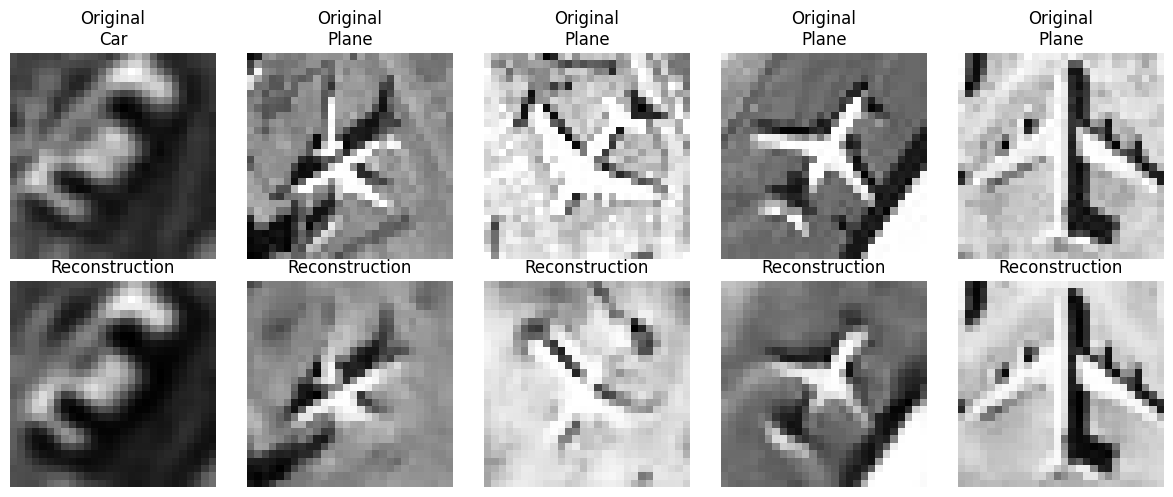

In [79]:
label_name = {0: "Car", 1: "Plane"}

decoded_test = modified2_autoencoder.predict(X_test)

np.random.seed(42)
idx = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,5))

for i, j in enumerate(idx):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[j].squeeze(), cmap='gray')
    plt.title(f"Original\n{label_name[y_test[j]]}")
    plt.axis('off')

    # Reconstruction
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_test[j].squeeze(), cmap='gray')
    plt.title("Reconstruction")
    plt.axis('off')

plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi, gambar hasil rekonstruksi pada Modified 2 mampu mempertahankan bentuk utama objek dengan lebih baik dibandingkan Modified 1. Kontur mobil dan pesawat terlihat lebih jelas serta pola visual utama berhasil direkonstruksi meskipun masih terdapat sedikit efek blur pada beberapa bagian. Hal ini menunjukkan bahwa peningkatan jumlah filter menjadi 128 serta penambahan Batch Normalization dan Dropout membantu model mempelajari representasi fitur yang lebih kaya sehingga kualitas rekonstruksi menjadi lebih baik.

## Kesimpulan Evaluasi SSIM Baseline vs Modified


In [80]:
avg_ssim = np.mean(scores)
comparison = pd.DataFrame({
    "Metric": [
        "Baseline SSIM",
        "Modified 1 SSIM",
        "Modified 2 SSIM",
        "Increase (%) Baseline → Modified 1",
        "Increase (%) Baseline → Modified 2",
        "Increase (%) Modified 1 → Modified 2"

    ],
    "Value": [
        avg_ssim,
        avg_ssim_mod,
        avg_ssim_mod2,
        ((avg_ssim_mod - avg_ssim) / avg_ssim) * 100,
        ((avg_ssim_mod2 - avg_ssim) / avg_ssim) * 100,
        ((avg_ssim_mod2 - avg_ssim_mod) / avg_ssim_mod2) * 100
    ]
})

comparison

,Metric,Value
0,Baseline SSIM,0.732148
1,Modified 1 SSIM,0.743158
2,Modified 2 SSIM,0.881357
3,Increase (%) Baseline → Modified 1,1.503814
4,Increase (%) Baseline → Modified 2,20.379533
5,Increase (%) Modified 1 → Modified 2,15.680173


Berdasarkan hasil evaluasi SSIM, model Baseline memperoleh nilai 0,7321, yang menunjukkan kualitas rekonstruksi awal. Setelah dilakukan modifikasi arsitektur pada Modified 1, nilai SSIM meningkat menjadi 0,7432 atau sekitar 1,50% dibandingkan Baseline. Peningkatan ini menunjukkan bahwa penambahan layer konvolusi, Batch Normalization, dan jumlah filter mampu memperbaiki kualitas rekonstruksi.

Pada Modified 2, kualitas rekonstruksi kembali meningkat dengan memperoleh nilai SSIM sebesar 0,8814, yaitu sekitar 20,38% lebih tinggi dibandingkan Baseline dan 15,68% lebih tinggi dibandingkan Modified 1. Hasil ini menunjukkan bahwa peningkatan jumlah filter serta penambahan Dropout berhasil meningkatkan kemampuan model dalam mempertahankan struktur gambar sehingga menghasilkan rekonstruksi yang lebih mendekati gambar asli.

## Hyperparameter Tuning

Pada tahap Hyperparameter Tuning, arsitektur model tetap sama seperti pada Modified 2.

Tapi ada tambahan berupa peningkatkan nilai Dropout dari 0,2 menjadi 0,3 untuk mengurangi ketergantungan model terhadap neuron tertentu dan membantu meningkatkan kemampuan generalisasi.


Batch size diubah dari 32 menjadi 16, sehingga proses pembaruan bobot (weight update) dilakukan lebih sering dalam setiap epoch. Hal ini memungkinkan model mempelajari pola data dengan lebih detail dan berpotensi menghasilkan konvergensi yang lebih baik.

Early Stopping dengan patience = 5, sehingga proses pelatihan akan dihentikan secara otomatis apabila nilai validation loss tidak mengalami perbaikan selama lima epoch berturut-turut. Penerapan hyperparameter tersebut bertujuan untuk memperoleh proses pelatihan yang lebih stabil, mengurangi risiko overfitting, serta meningkatkan kualitas rekonstruksi gambar.

### Training

In [81]:
from tensorflow.keras.optimizers import Adam
input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = BatchNormalization()(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Flatten()(x)

x = Dropout(0.3)(x) # ubah drop out dari 0.2 jadi 0.3

latent = Dense(
    128,
    activation='relu',
    name='latent'
)(x)

# Decoder


x = Dense(
    14*14*128,
    activation='relu'
)(latent)

x = Reshape((14,14,128))(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

output = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

modifiedlr_autoencoder = Model(input_img, output)


modifiedlr_autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

modifiedlr_autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25088)          │     3,236,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,820,353 (26.02 MB)

 Trainable params: 6,819,457 (26.01 MB)

 Non-trainable params: 896 (3.50 KB)

In [82]:
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [83]:
history_modifiedlr_autoencoder = modifiedlr_autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=16,          # tuning batch size
    callbacks=[earlystop],
    verbose=1
)

Epoch 1/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - loss: 0.0273 - mae: 0.1164 - val_loss: 0.0172 - val_mae: 0.0929
Epoch 2/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0131 - mae: 0.0776 - val_loss: 0.0124 - val_mae: 0.0772
Epoch 3/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0103 - mae: 0.0677 - val_loss: 0.0114 - val_mae: 0.0695
Epoch 4/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0087 - mae: 0.0615 - val_loss: 0.0099 - val_mae: 0.0717
Epoch 5/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0077 - mae: 0.0574 - val_loss: 0.0085 - val_mae: 0.0568
Epoch 6/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0071 - mae: 0.0551 - val_loss: 0.0068 - val_mae: 0.0519
Epoch 7/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0067 - mae: 0.0537 - val_loss: 0.0077 - val_mae: 0.0540
Epoch 8/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0063 - mae: 0.0518 - val_loss: 0.0079 - val_mae: 0.0550
Epoch 9/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms

### Train Evaluation

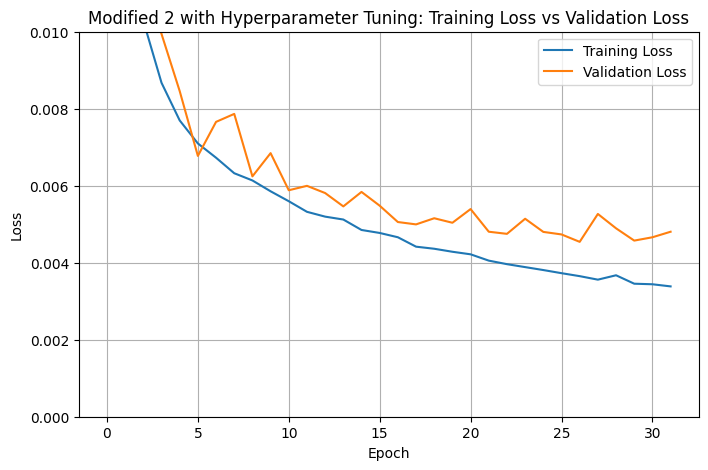

In [96]:
plt.figure(figsize=(8,5))

plt.plot(history_modifiedlr_autoencoder.history['loss'], label='Training Loss')
plt.plot(history_modifiedlr_autoencoder.history['val_loss'], label='Validation Loss')

plt.title('Modified 2 with Hyperparameter Tuning: Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.ylim(0, 0.01)

plt.legend()
plt.grid(True)
plt.show()

In [97]:
best_epoch_mod12 = np.argmin(history_modifiedlr_autoencoder.history['val_loss']) + 1
best_val_loss_mod12 = np.min(history_modifiedlr_autoencoder.history['val_loss'])

print("Best Epoch :", best_epoch_mod12)
print("Best Validation Loss :", best_val_loss_mod12)

Best Epoch : 27
Best Validation Loss : 0.0045421491377055645


training loss mengalami penurunan secara konsisten selama proses pelatihan. Validation loss juga menurun pada beberapa epoch awal, namun setelah mencapai nilai terbaik pada epoch ke-27 sebesar 0,00454, validation loss cenderung berfluktuasi dan tidak menunjukkan penurunan yang signifikan. Meskipun demikian, selisih antara training loss dan validation loss masih relatif kecil sehingga model masih mampu melakukan generalisasi dengan cukup baik dan tidak mengalami overfitting yang berlebihan.

Dibandingkan dengan Modified 2, perubahan hyperparameter berupa peningkatan Dropout dari 0,2 menjadi 0,3, pengurangan batch size dari 32 menjadi 16, serta penerapan Early Stopping dengan patience 5 menghasilkan nilai validation loss yang sedikit lebih rendah dan model mencapai performa terbaik lebih cepat, yaitu pada epoch ke-27. Namun, peningkatan kualitas rekonstruksi yang diperoleh relatif kecil dibandingkan Modified 2 sehingga perubahan hyperparameter ini belum memberikan peningkatan performa yang signifikan.

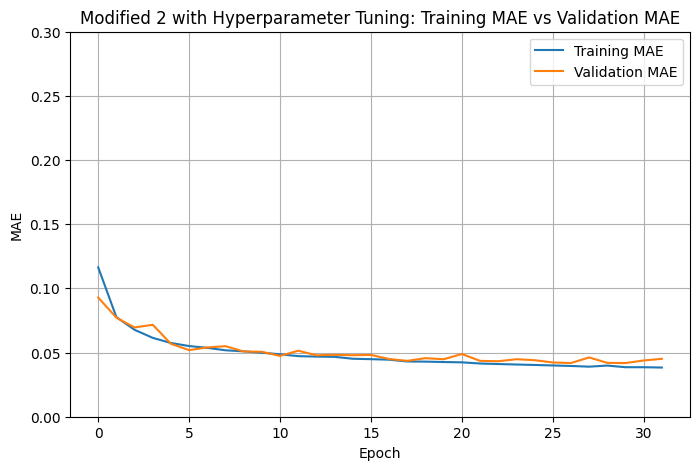

In [98]:
plt.figure(figsize=(8,5))

plt.plot(history_modifiedlr_autoencoder.history['mae'], label='Training MAE')
plt.plot(history_modifiedlr_autoencoder.history['val_mae'], label='Validation MAE')

plt.title('Modified 2 with Hyperparameter Tuning: Training MAE vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.ylim(0, 0.30)

plt.legend()
plt.grid(True)
plt.show()

In [99]:
print("Train Loss :", history_modifiedlr_autoencoder.history['loss'][-1])
print("Val Loss   :", history_modifiedlr_autoencoder.history['val_loss'][-1])

print("Train MAE  :", history_modifiedlr_autoencoder.history['mae'][-1])
print("Val MAE    :", history_modifiedlr_autoencoder.history['val_mae'][-1])

Train Loss : 0.0033852383494377136
Val Loss   : 0.004804995376616716
Train MAE  : 0.038320399820804596
Val MAE    : 0.04513527825474739


Kurva training MAE dan validation MAE saling berdekatan dengan selisih yang relatif kecil, yaitu 0,0383 untuk training MAE dan 0,0451 untuk validation MAE. Hal ini menunjukkan bahwa model mampu melakukan generalisasi dengan cukup baik dan tidak mengalami overfitting yang signifikan. Meskipun validation MAE masih sedikit lebih tinggi daripada training MAE, perbedaannya tidak terlalu besar sehingga proses pelatihan dapat dikatakan stabil dan menghasilkan kualitas rekonstruksi yang cukup baik.

### Test Prediction

In [100]:
decoded_lr = modifiedlr_autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [101]:
test_loss_lr, test_mae_lr = modifiedlr_autoencoder.evaluate(
    X_test,
    X_test,
    verbose=0
)

print("Test Loss :", test_loss_lr)
print("Test MAE  :", test_mae_lr)

Test Loss : 0.0046720681712031364
Test MAE  : 0.04236439988017082


Test Loss sebesar 0,00467 dan Test MAE sebesar 0,04236. Nilai tersebut cukup rendah dan mendekati nilai validation loss serta validation MAE selama proses pelatihan. Hal ini menunjukkan bahwa model mampu melakukan generalisasi dengan baik pada data yang belum pernah dilihat sebelumnya.

### Evaluasi SSIM

In [102]:
from skimage.metrics import structural_similarity as ssim

scores_lr = []

for i in range(len(X_test)):
    score = ssim(
        X_test[i].squeeze(),
        decoded_lr[i].squeeze(),
        data_range=1.0
    )
    scores_lr.append(score)

avg_ssim_lr = np.mean(scores_lr)

print("Average SSIM =", avg_ssim_lr)

Average SSIM = 0.8917333486214305


model Hyperparameter Tuning memperoleh Average SSIM sebesar 0,8917, yang merupakan nilai tertinggi dibandingkan seluruh model sebelumnya. Nilai SSIM yang semakin mendekati 1 menunjukkan bahwa gambar hasil rekonstruksi memiliki tingkat kemiripan yang sangat tinggi dengan gambar asli.


Tapi model ini (di analisis grafik train sebelumnya) menunjukkan bahwa model masih memiliki kecenderungan mengalami overfitting ringan, meskipun penggunaan Dropout sebesar 0,3, batch size 16, dan Early Stopping telah membantu meningkatkan kemampuan generalisasi model. Dengan demikian, kualitas rekonstruksi sudah sangat baik berdasarkan nilai SSIM, namun proses pelatihannya masih dapat dioptimalkan agar menghasilkan performa yang lebih stabil.


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


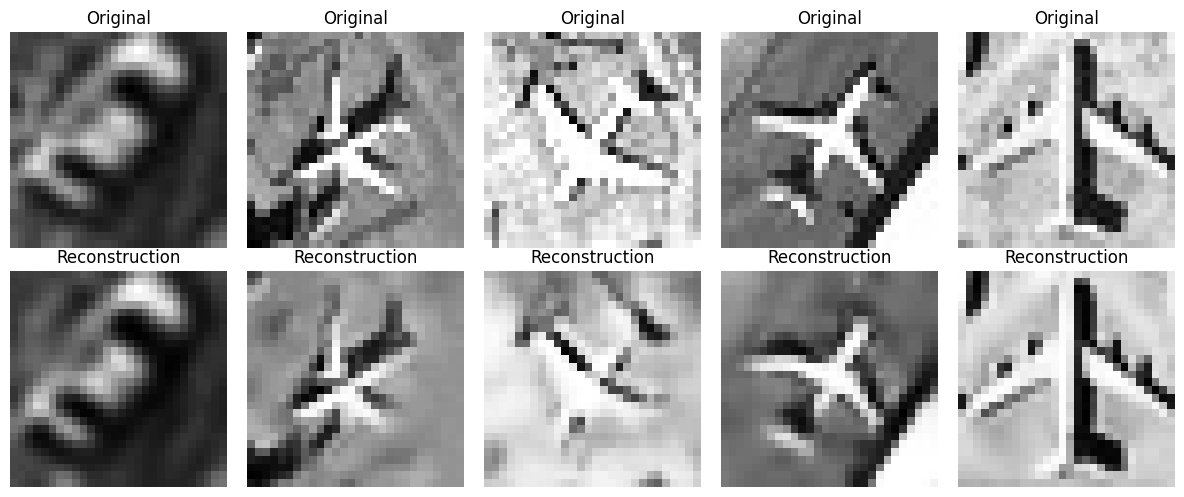

In [103]:
decoded_lr = modifiedlr_autoencoder.predict(X_test)

np.random.seed(42)
idx = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,5))

for i, j in enumerate(idx):

    # Gambar asli
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[j].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Hasil rekonstruksi
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_lr[j].squeeze(), cmap='gray')
    plt.title("Reconstruction")
    plt.axis('off')

plt.tight_layout()
plt.show()

Hyperparameter Tuning memiliki tingkat kemiripan yang tinggi dengan gambar asli. Bentuk utama objek, baik pada kelas Car maupun Plane, masih dapat dipertahankan dengan baik meskipun terdapat sedikit penghalusan (smoothing) pada beberapa bagian dan detail berukuran kecil.

Namun, pada Hyperparameter Tuning 1 masih terlihat sedikit efek smoothing sehingga beberapa detail halus tampak lebih kabur. Sebaliknya, hasil rekonstruksi Modified 2 cenderung mempertahankan kontur objek dengan lebih konsisten dan menghasilkan tampilan yang sedikit lebih tajam pada beberapa sampel. Meskipun perbedaan visualnya tidak terlalu signifikan, hasil rekonstruksi Modified 2 terlihat lebih stabil secara keseluruhan.

## Hyperparameter Tuning 2

### Train

In [108]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import *

input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = BatchNormalization()(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Flatten()(x)

# Hyperparameter Tuning
x = Dropout(0.3)(x)

latent = Dense(
    256,   # Latent dimension diubah menjadi 256
    activation='relu',
    name='latent'
)(x)

# Decoder

x = Dense(
    14 * 14 * 128,
    activation='relu'
)(latent)

x = Reshape((14,14,128))(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

output = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

# Model
hyperparameter_tuning2_autoencoder = Model(
    input_img,
    output,
    name="Hyperparameter_Tuning_2"
)

hyperparameter_tuning2_autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

hyperparameter_tuning2_autoencoder.summary()

history_hyperparameter_tuning2 = hyperparameter_tuning2_autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=16,
    callbacks=[earlystop],
    verbose=1
)

Model: "Hyperparameter_Tuning_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25088)          │     6,447,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,243,009 (50.52 MB)

 Trainable params: 13,242,113 (50.51 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 0.0251 - mae: 0.1101 - val_loss: 0.0139 - val_mae: 0.0817
Epoch 2/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0117 - mae: 0.0728 - val_loss: 0.0108 - val_mae: 0.0667
Epoch 3/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0090 - mae: 0.0629 - val_loss: 0.0097 - val_mae: 0.0641
Epoch 4/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0078 - mae: 0.0583 - val_loss: 0.0068 - val_mae: 0.0533
Epoch 5/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0068 - mae: 0.0542 - val_loss: 0.0065 - val_mae: 0.0513


Hyperparameter Tuning 2, arsitektur model tetap sama seperti Hyperparameter Tuning 1. Perubahan hanya dilakukan pada latent dimension, yaitu dari 128 menjadi 256, sementara Dropout 0,3, batch size 16, dan Early Stopping (patience = 5) tetap digunakan. Peningkatan latent dimension bertujuan memberikan ruang representasi yang lebih besar agar model dapat menyimpan informasi gambar lebih banyak sehingga kualitas rekonstruksi diharapkan menjadi lebih baik.

### Train Evaluation

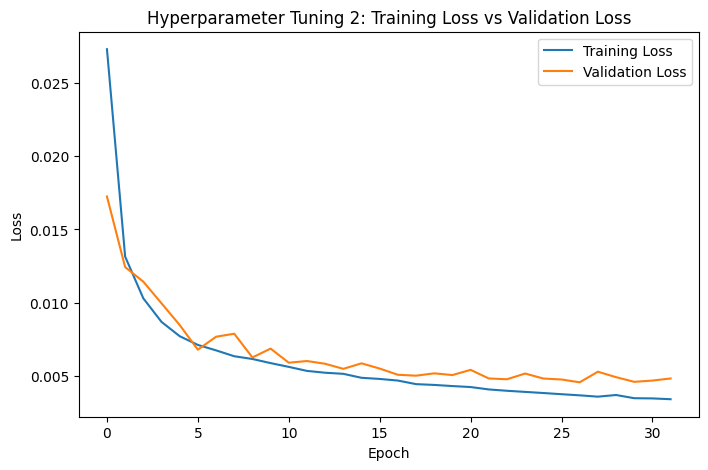

In [113]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.plot(history_modifiedlr_autoencoder.history['loss'], label='Training Loss')
plt.plot(history_modifiedlr_autoencoder.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Hyperparameter Tuning 2: Training Loss vs Validation Loss')
plt.legend()
plt.show()

In [137]:
best_epoch = np.argmin(history_hyperparameter_tuning2.history['val_loss']) + 1
best_val_loss = np.min(history_hyperparameter_tuning2.history['val_loss'])

print("Best Epoch :", best_epoch)
print("Best Validation Loss :", best_val_loss)

Best Epoch : 5
Best Validation Loss : 0.006472622510045767


In [136]:
print("Train Loss :", history_modifiedlr_autoencoder.history['loss'][-1])
print("Val Loss   :", history_modifiedlr_autoencoder.history['val_loss'][-1])

print("Train MAE  :", history_modifiedlr_autoencoder.history['mae'][-1])
print("Val MAE    :", history_modifiedlr_autoencoder.history['val_mae'][-1])

Train Loss : 0.0033852383494377136
Val Loss   : 0.004804995376616716
Train MAE  : 0.038320399820804596
Val MAE    : 0.04513527825474739


Grafik, training loss dan validation loss mengalami penurunan pada awal proses pelatihan, kemudian menurun secara bertahap hingga akhir epoch. Nilai validation loss terbaik diperoleh pada epoch ke-5, yaitu sebesar 0,00647. Setelah epoch tersebut, validation loss mulai berfluktuasi dan tidak menunjukkan perbaikan. Hal ini menunjukkan adanya kecenderungan model mulai mengalami overfitting ringan setelah epoch ke-5.

### Test Prediction

In [124]:
decoded_hyper2 = hyperparameter_tuning2_autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [138]:
ssim_scores = []

for i in range(len(X_test)):
    score = ssim(
        X_test[i].squeeze(),
        decoded_hyper2[i].squeeze(),
        data_range=1.0
    )
    ssim_scores.append(score)

average_ssim = np.mean(ssim_scores)

print(f"Average SSIM: {average_ssim:.4f}")

Average SSIM: 0.7110


model Hyperparameter Tuning 2 memperoleh nilai Average SSIM sebesar 0,7110. Nilai ini lebih rendah dibandingkan Modified 2 yang memperoleh SSIM sebesar 0,8814, sehingga kualitas rekonstruksi mengalami penurunan. Hal ini menunjukkan bahwa peningkatan latent dimension dari 128 menjadi 256 tidak memberikan representasi yang lebih baik pada dataset ini.

### Comparison Baseline dengan model lain

In [140]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline (autoencoder)",
        "Modified 1 (modified_autoencoder)",
        "Modified 2 (modified2_autoencoder)",
        "Hyperparameter Tuning (modifiedlr_autoencoder)",
        "Hyperparameter Tuning 2 (hyperparameter_tuning_2)"
    ],
    "Latent Dimension": [
        128,
        128,
        128,
        128,
        256
    ],
    "Average SSIM": [
        avg_ssim,
        avg_ssim_mod,
        avg_ssim_mod2,
        avg_ssim_lr,
        average_ssim
    ]
})

# Hitung peningkatan dibanding baseline
baseline = avg_ssim

comparison["Improvement vs Baseline (%)"] = (
    (comparison["Average SSIM"] - baseline) / baseline * 100
)

comparison["Average SSIM"] = comparison["Average SSIM"].round(4)
comparison["Improvement vs Baseline (%)"] = comparison["Improvement vs Baseline (%)"].round(2)

comparison

,Model,Latent Dimension,Average SSIM,Improvement vs Baseline (%)
0,Baseline (autoencoder),128,0.7321,0.00
1,Modified 1 (modified_autoencoder),128,0.7432,1.50
2,Modified 2 (modified2_autoencoder),128,0.8814,20.38
3,Hyperparameter Tuning (modifiedlr_autoencoder),128,0.8917,21.80
4,Hyperparameter Tuning 2 (hyperparameter_tuning_2),256,0.7110,-2.89


Model Baseline masih menggunakan arsitektur yang sederhana sehingga kemampuan dalam merekonstruksi gambar masih terbatas, dengan nilai SSIM sebesar 0,7321. Oleh karena itu, dilakukan beberapa modifikasi pada arsitektur model untuk meningkatkan kualitas rekonstruksi.

Pada Modified 1, jumlah filter Conv2D ditingkatkan dari 32 menjadi 64, ditambahkan Batch Normalization, serta jumlah layer konvolusi encoder diperbanyak. Perubahan ini meningkatkan kualitas rekonstruksi dengan nilai SSIM sebesar 0,7432, atau sekitar 1,50% lebih tinggi dibandingkan Baseline.

Selanjutnya, pada Modified 2, jumlah filter kembali ditingkatkan menjadi 128 dan ditambahkan Dropout sebesar 0,2 untuk membantu mengurangi risiko overfitting. Hasilnya, nilai SSIM meningkat menjadi 0,8814, atau sekitar 20,38% lebih tinggi dibandingkan Baseline. Hal ini menunjukkan bahwa peningkatan kapasitas model yang disertai regularisasi mampu meningkatkan kualitas rekonstruksi gambar secara signifikan.

Pada tahap Hyperparameter Tuning, dilakukan penyesuaian Dropout dari 0,2 menjadi 0,3, batch size dari 32 menjadi 16, serta penerapan Early Stopping dengan patience 5. Kombinasi hyperparameter tersebut menghasilkan nilai SSIM sebesar 0,8917, atau sekitar 21,80% lebih tinggi dibandingkan Baseline. Nilai ini merupakan yang tertinggi di antara seluruh model, namun peningkatannya dibandingkan Modified 2 hanya sekitar 1,17%.

Pada Hyperparameter Tuning 2, latent dimension kemudian ditingkatkan dari 128 menjadi 256 dengan hyperparameter lainnya tetap dipertahankan. Akan tetapi, model hanya memperoleh nilai SSIM sebesar 0,7110, atau sekitar 2,89% lebih rendah dibandingkan Baseline. Hasil ini menunjukkan bahwa peningkatan latent dimension tidak selalu menghasilkan performa yang lebih baik. Pada dataset ini, latent dimension sebesar 128 sudah cukup untuk merepresentasikan informasi gambar, sedangkan peningkatan menjadi 256 justru menurunkan kualitas rekonstruksi.

Secara keseluruhan, Modified 2 dipilih sebagai model terbaik karena mampu memberikan keseimbangan yang baik antara kualitas rekonstruksi, kompleksitas arsitektur, dan efisiensi model. Meskipun Hyperparameter Tuning menghasilkan nilai SSIM yang sedikit lebih tinggi (0,8917), peningkatannya relatif kecil dibandingkan Modified 2 (0,8814). Dengan latent dimension yang tetap 128 dan arsitektur yang lebih sederhana, Modified 2 dinilai lebih optimal untuk menghasilkan rekonstruksi gambar yang berkualitas tanpa meningkatkan kompleksitas model secara berlebihan.

In [105]:
decoded_base = autoencoder.predict(X_test)
decoded_mod1 = modified_autoencoder.predict(X_test)
decoded_mod2 = modified2_autoencoder.predict(X_test)
decoded_hyper = modifiedlr_autoencoder.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


# Rangkuman Hasil 

## Perbandingan Arsitektur

| Komponen | Baseline | Modified 1 | Modified 2 | Hyperparameter Tuning 1 | Hyperparameter Tuning 2 |
|----------|----------|------------|------------|-------------------------|-------------------------|
| Conv Encoder | 1 × Conv2D (32 filter) | 2 × Conv2D (64 filter) | 2 × Conv2D (128 filter) | Sama seperti Modified 2 | Sama seperti Hyperparameter Tuning 1 |
| Batch Normalization | ❌ | 2 layer | 4 layer | 4 layer | 4 layer |
| MaxPooling | 1 | 1 | 1 | 1 | 1 |
| Flatten | ✓ | ✓ | ✓ | ✓ | ✓ |
| Dropout | ❌ | ❌ | 0.2 | 0.3 | 0.3 |
| Latent Dimension | 128 | 128 | 128 | 128 | 256 |
| Dense Decoder | 14×14×32 | 14×14×64 | 14×14×128 | 14×14×128 | 14×14×128 |
| UpSampling | 1 | 1 | 1 | 1 | 1 |
| Conv Decoder | 32 → Output | 64 → 32 → Output | 128 → 64 → Output | Sama seperti Modified 2 | Sama seperti Hyperparameter Tuning 1 |
| Optimizer | Adam | Adam | Adam | Adam | Adam |
| Loss Function | MSE | MSE | MSE | MSE | MSE |
| Metric | MAE | MAE | MAE | MAE | MAE |
| Batch Size | 32 | 32 | 32 | 16 | 16 |
| Epoch | 30 | 50 | 50 | 50 | 50 |
| Early Stopping | ❌ | Patience = 10 | Patience = 10 | Patience = 5 | Patience = 5 |

---

## Perubahan Tiap Model

### Baseline
- Menggunakan arsitektur Autoencoder sesuai dengan soal.
- Encoder terdiri dari 1 layer Conv2D dengan 32 filter.
- Latent dimension sebesar 128.
- Menggunakan MSE sebagai loss function dan MAE sebagai metrik evaluasi.

### Modified 1
- Menambahkan 1 layer Conv2D pada encoder sehingga menjadi 2 layer.
- Jumlah filter ditingkatkan dari 32 menjadi 64.
- Menambahkan Batch Normalization pada encoder dan decoder.
- Latent dimension tetap 128.
- Decoder diperbesar agar sesuai dengan perubahan encoder.

### Modified 2
- Jumlah filter encoder dan decoder ditingkatkan menjadi 128.
- Batch Normalization ditambahkan pada seluruh blok encoder dan decoder.
- Menambahkan Dropout sebesar 0.2 sebelum latent layer untuk membantu mengurangi overfitting.
- Latent dimension tetap 128.

### Hyperparameter Tuning 1
- Arsitektur tetap sama dengan Modified 2.
- Nilai Dropout ditingkatkan dari 0.2 menjadi 0.3.
- Batch Size diubah dari 32 menjadi 16.
- Early Stopping diubah menjadi patience = 5.

### Hyperparameter Tuning 2
- Menggunakan arsitektur yang sama dengan Hyperparameter Tuning 1.
- Latent Dimension ditingkatkan dari 128 menjadi 256.
- Dropout tetap 0.3.
- Batch Size tetap 16.
- Early Stopping tetap menggunakan patience = 5.

**Challenges & Opportunities**

Salah satu tantangan dalam project ini adalah menentukan arsitektur autoencoder dan kombinasi hyperparameter yang paling optimal karena setiap perubahan belum tentu meningkatkan performa model. Selain itu, model juga berisiko mengalami overfitting apabila arsitekturnya terlalu kompleks atau proses training tidak dikontrol dengan baik. Meskipun demikian, penelitian ini masih memiliki peluang untuk dikembangkan, seperti menggunakan dataset yang lebih besar dan beragam, mencoba arsitektur autoencoder yang lebih canggih, serta menerapkan metode hyperparameter tuning otomatis agar diperoleh performa rekonstruksi yang lebih optimal dan dapat diaplikasikan pada berbagai tugas pengolahan citra di dunia nyata.

**Kritik dan Saran**

Meskipun model sudah memberikan hasil yang baik, performanya masih dapat ditingkatkan dengan menambah variasi dataset serta mencoba metode dan konfigurasi model yang lebih optimal
